In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
from sklearn.metrics import f1_score


from pathlib import Path
import sys

MAL_DIR = Path.cwd()
if MAL_DIR.name != "MAL":
    MAL_DIR = next(path for path in [Path.cwd(), *Path.cwd().parents] if path.name == "MAL")

sys.path.insert(0, str(MAL_DIR))
from scripts.preprocessing import AutomatedPreprocessor

# Here we import and split the data
df = pd.read_csv("../../data/processed/sessions_scored_30min.csv")

TARGET_COLUMN = "focus_score"
columns_to_ignore = [TARGET_COLUMN]

feature_columns = [
    column for column in df.columns
    if column not in columns_to_ignore and pd.api.types.is_numeric_dtype(df[column])
]

X = df[feature_columns].copy()
y = df[TARGET_COLUMN].copy()

X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val, test_size=0.2, random_state=42, stratify=y_train_val
)

# Usage from scripts/
preprocessor = AutomatedPreprocessor()
X_train_processed = preprocessor.fit_transform(X_train)
X_val_processed = preprocessor.transform(X_val)
X_test_processed = preprocessor.transform(X_test)


In [2]:
# Random Forest Classification

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

param_grid = {
    "n_estimators": [100, 200, 400],
    "max_depth": [5, 10, 20],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "class_weight": ["balanced"],
}

rf = RandomForestClassifier(random_state=42, n_jobs=-1)

grid_search = GridSearchCV(
    rf,
    param_grid,
    cv=3,
    scoring="f1_macro",
    n_jobs=-1
)
grid_search.fit(X_train_processed, y_train)

best_model = grid_search.best_estimator_
print(f"Best Parameters: {grid_search.best_params_}")
print(f"Best CV f1_macro: {grid_search.best_score_:.4f}")

results_df = pd.DataFrame(grid_search.cv_results_)
results_df = results_df[[
    "mean_test_score",
    "std_test_score",
    "mean_fit_time",
    "param_n_estimators",
    "param_max_depth",
    "param_min_samples_split",
    "param_min_samples_leaf",
    "param_class_weight",
]].sort_values(by="mean_test_score", ascending=False)

results_df

Best Parameters: {'class_weight': 'balanced', 'max_depth': 20, 'min_samples_leaf': 1, 'min_samples_split': 10, 'n_estimators': 100}
Best CV f1_macro: 0.2063


,mean_test_score,std_test_score,mean_fit_time,param_n_estimators,param_max_depth,param_min_samples_split,param_min_samples_leaf,param_class_weight
60,0.206308,0.000950,13.259841,100,20,10,1,balanced
78,0.205664,0.001484,11.806992,100,20,10,4,balanced
79,0.204985,0.002700,22.496665,200,20,10,4,balanced
72,0.204982,0.000943,13.330321,100,20,2,4,balanced
75,0.204982,0.000943,13.547270,100,20,5,4,balanced
...,...,...,...,...,...,...,...,...
26,0.167725,0.012779,13.384581,400,5,10,4,balanced
11,0.167543,0.011223,21.157524,400,5,2,2,balanced
20,0.167481,0.012243,13.465568,400,5,2,4,balanced
23,0.167481,0.012243,12.878364,400,5,5,4,balanced



--- Train Metrics ---
Accuracy:  0.9337
Precision (weighted): 0.9345
Recall (weighted):    0.9337
F1 Score (weighted):  0.9337

--- Test/Validation Metrics ---
Accuracy:  0.2335
Precision (weighted): 0.2285
Recall (weighted):    0.2335
F1 Score (weighted):  0.2305

--- Feature Importances (Top 20) ---
co2_std_co2_range                                                                              0.098494
temperature_mean_temperature_max_temperature_min_temperature_latest                            0.097607
co2_mean_co2_max_co2_min_co2_latest                                                            0.094084
light_mean_light_max                                                                           0.091638
light_std_light_range                                                                          0.091011
light_latest                                                                                   0.084915
noise_min_noise_latest_noise_mean_noise_max                             

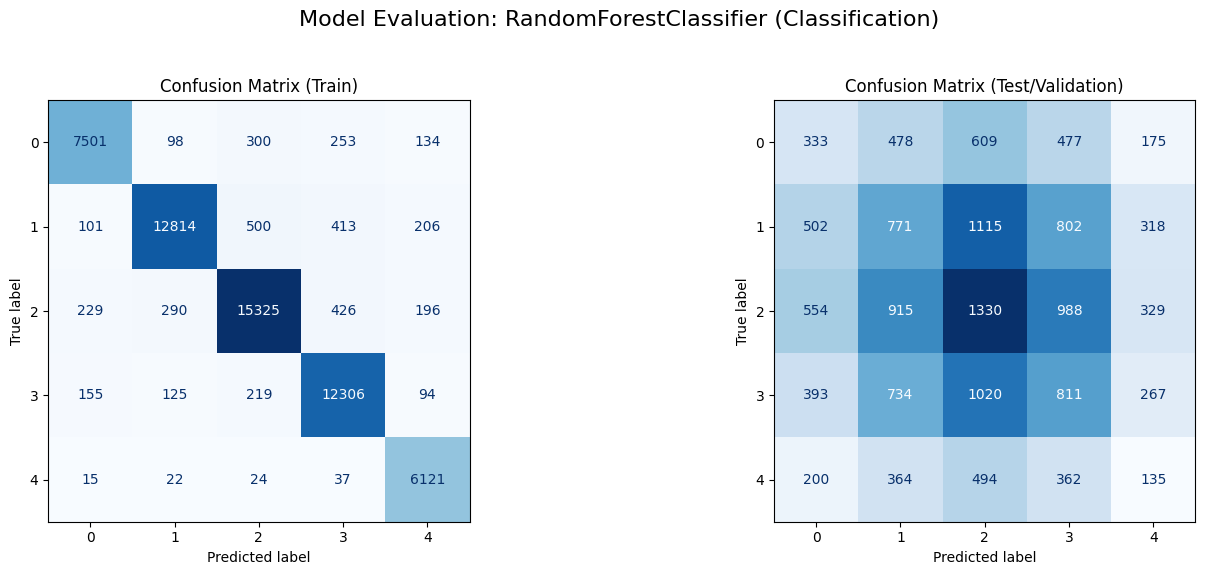

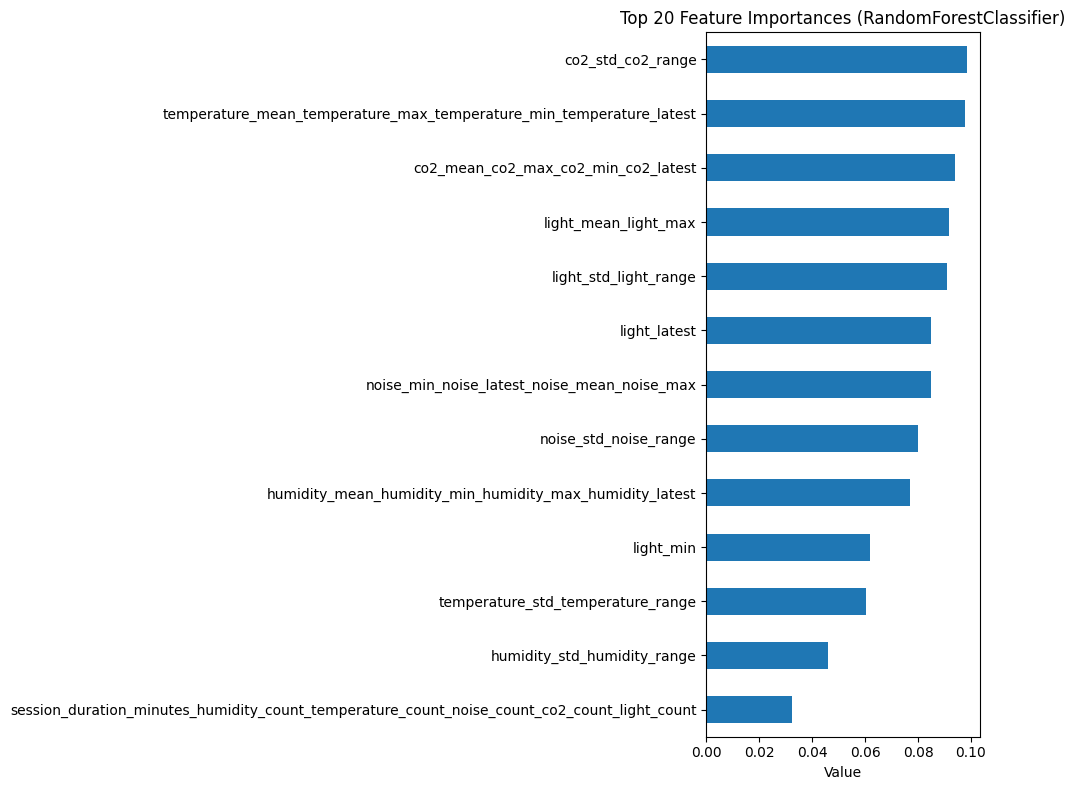

In [3]:
import importlib
import scripts.evaluation_metrics
importlib.reload(scripts.evaluation_metrics)
from scripts.evaluation_metrics import evaluate_model

best_model.fit(X_train_processed, y_train)

evaluate_model(best_model, X_train_processed, X_val_processed, y_train, y_val, True);

## Conclusion

The Random Forest Classifier currently appears to be the best choice for our prediction task.

It handles the imbalanced nature of our dataset better than the simple linear models in Notebook 5 and matches (or even exceeds) the performance of the neural networks in Notebook 4. The weighted approach (class_weight='balanced') is particularly effective at catching rare ratings without sacrificing too much overall accuracy.

Unlike the Neural Networks, the Random Forest is much less prone to overfitting on our small dataset. It also provides a clear 'Feature Importance' ranking which is very useful for our project development.

Going forward, this model strikes the best balance between performance, explainability, and ease of deployment. While Neural Networks (Notebook 4) might eventually win with more data, the Random Forest is our current champion for production use.
